In [82]:
# Import Library
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, auc

In [83]:
# Load Dataset
data = pd.read_excel("Dataset_Kualitas_Air_1000.xlsx")
data.columns = data.columns.str.strip()

print(data.head())

     Tanggal  Temperatur    pH    DO   BOD   COD  TSS   TDS
0 2014-03-09        26.0  7.07  5.37  2.14  15.9   32   480
1 2014-03-09        25.9  6.99  5.44  2.14  16.0   32   480
2 2014-03-09        25.8  6.92  5.54  2.14  16.0   32   480
3 2014-03-09        25.7  6.69  5.60  2.18  16.0   32   480
4 2014-03-09        26.5  6.36  3.90  3.10  26.0   52  1001


In [84]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Tanggal     1000 non-null   datetime64[ns]
 1   Temperatur  1000 non-null   float64       
 2   pH          1000 non-null   float64       
 3   DO          1000 non-null   float64       
 4   BOD         1000 non-null   float64       
 5   COD         1000 non-null   float64       
 6   TSS         1000 non-null   int64         
 7   TDS         1000 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 62.6 KB


,Tanggal,Temperatur,pH,DO,BOD,COD,TSS,TDS
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2020-01-22 00:31:40.800000256,28.448500,5.924750,3.636240,4.126690,29.540800,61.794000,1092.252000
min,2014-03-09 00:00:00,25.700000,5.000000,2.000000,1.330000,15.900000,32.000000,480.000000
25%,2017-03-04 00:00:00,27.500000,5.000000,2.730000,2.990000,25.000000,50.000000,1000.000000
50%,2020-03-02 00:00:00,27.800000,6.250000,3.900000,3.450000,26.900000,55.000000,1040.000000
75%,2023-03-04 00:00:00,29.300000,6.420000,4.400000,5.635000,33.300000,70.000000,1160.000000
max,2025-08-18 00:00:00,31.500000,7.720000,5.600000,6.500000,45.000000,120.000000,1600.000000
std,NaN,1.422597,0.679444,0.995495,1.486878,6.245881,16.946703,140.063236


In [85]:
# Preprocessing
fitur = ["Temperatur", "pH", "DO", "BOD", "COD", "TSS", "TDS"]

data[fitur] = data[fitur].apply(pd.to_numeric, errors="coerce")

imputer = SimpleImputer(strategy="mean")
data[fitur] = imputer.fit_transform(data[fitur])

print("Missing value setelah imputasi:")
print(data[fitur].isnull().sum())

Missing value setelah imputasi:
Temperatur    0
pH            0
DO            0
BOD           0
COD           0
TSS           0
TDS           0
dtype: int64


In [86]:
# Penentuan Label Kualitas Air berdasarkan PP 22/2021 Kelas II

# BAKU MUTU PP 22/2021 KELAS II
BM = {
    "pH_min": 6,
    "pH_max": 9,
    "DO": 4,
    "BOD": 3,
    "COD": 25,
    "TSS": 50,
    "TDS": 1000,
    "Temperatur": 3
}

# Temperatur alami sesuai keputusan Anda
TEMP_ALAMI = 28

# ===============================
# FUNGSI HITUNG IP
# ===============================
def hitung_ip(row):
    rasio = []

    # pH (metode rentang sesuai Kepmen)
    L_min = BM["pH_min"]
    L_max = BM["pH_max"]
    L_mid = (L_min + L_max) / 2

    if row["pH"] < L_mid:
        r = (L_mid - row["pH"]) / (L_mid - L_min)
    else:
        r = (row["pH"] - L_mid) / (L_max - L_mid)
    rasio.append(abs(r))

    # DO
    r = BM["DO"] / row["DO"]
    rasio.append(r)

    # BOD, COD, TSS, TDS
    for p in ["BOD", "COD", "TSS", "TDS"]:
        rasio.append(row[p] / BM[p])

    # Temperatur
    dev = abs(row["Temperatur"] - TEMP_ALAMI)
    rasio.append(dev / BM["Temperatur"])

    R = np.mean(rasio)
    M = np.max(rasio)

    return np.sqrt((M**2 + R**2) / 2)


In [87]:
data["IP"] = data.apply(hitung_ip, axis=1)

print("Kolom IP berhasil dibuat")
print(data[["IP"]].head())

def label_ip_binary(ip):
    return 0 if ip <= 1 else 1

data["Label_IP"] = data["IP"].apply(label_ip_binary)

print(data["Label_IP"].value_counts())

Kolom IP berhasil dibuat
         IP
0  0.674278
1  0.674182
2  0.677431
3  0.707970
4  0.979161
Label_IP
1    516
0    484
Name: count, dtype: int64


In [88]:
# Time Shift (Target = Kondisi Berikutnya)
# Geser label untuk target waktu berikutnya (t+1)
data["Target"] = data["Label_IP"].shift(-1)

# Buang baris terakhir yang target-nya NaN
data = data.dropna().reset_index(drop=True)

# Tampilkan SEMUA FITUR + Label + Target
kolom_time_aware = fitur + ["Label_IP", "Target"]
data[kolom_time_aware].head(10)

,Temperatur,pH,DO,BOD,COD,TSS,TDS,Label_IP,Target
0,26.0,7.07,5.37,2.14,15.9,32.0,480.0,0,0.0
1,25.9,6.99,5.44,2.14,16.0,32.0,480.0,0,0.0
2,25.8,6.92,5.54,2.14,16.0,32.0,480.0,0,0.0
3,25.7,6.69,5.60,2.18,16.0,32.0,480.0,0,0.0
4,26.5,6.36,3.90,3.10,26.0,52.0,1001.0,0,1.0
5,27.0,5.94,3.48,3.82,28.0,57.0,1041.0,1,1.0
6,27.5,5.32,3.12,4.47,30.1,62.0,1081.0,1,1.0
7,28.1,5.00,2.81,5.08,32.2,67.0,1121.0,1,1.0
8,28.7,5.00,2.50,5.92,34.3,72.0,1161.0,1,1.0
9,29.2,5.00,2.00,6.50,36.5,77.0,1202.0,1,1.0


In [89]:
# Split Data Latih & Uji
X = data[fitur]
y = data["Target"]

split_idx = int(0.9 * len(data))

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]

print(X_train.shape, X_test.shape)

(899, 7) (100, 7)


In [90]:
# Training Model
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    max_depth=3,
    learning_rate=0.01,
    n_estimators=100,
    subsample=1.0,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)
print("Model selesai dilatih")

Model selesai dilatih


In [91]:
# SIMPAN MODEL FINAL UTAMA
model_final = model

# SIMPAN DATA TEST FINAL
X_test_final = X_test.copy()
y_test_final = y_test.copy()

In [92]:
# metadata = {
#     "fitur": fitur,
#     "baku_mutu": "PP No. 22 Tahun 2021 Kelas II",
#     "split_ratio": "90:10",
#     "model_type": "XGBoost Binary Classification"
# }

# joblib.dump(metadata, "metadata_model.pkl")

In [93]:
# Evaluasi Model
y_pred = model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))
print(classification_report(
    y_test, y_pred,
    target_names=["Memenuhi Baku Mutu", "Tidak Memenuhi"]
))

Akurasi: 0.85
                    precision    recall  f1-score   support

Memenuhi Baku Mutu       0.88      0.83      0.86        54
    Tidak Memenuhi       0.82      0.87      0.84        46

          accuracy                           0.85       100
         macro avg       0.85      0.85      0.85       100
      weighted avg       0.85      0.85      0.85       100



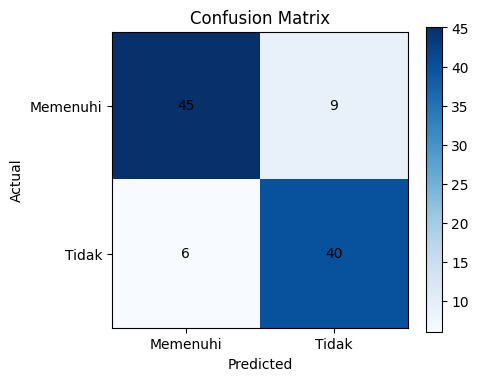

In [94]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks([0,1], ["Memenuhi", "Tidak"])
plt.yticks([0,1], ["Memenuhi", "Tidak"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

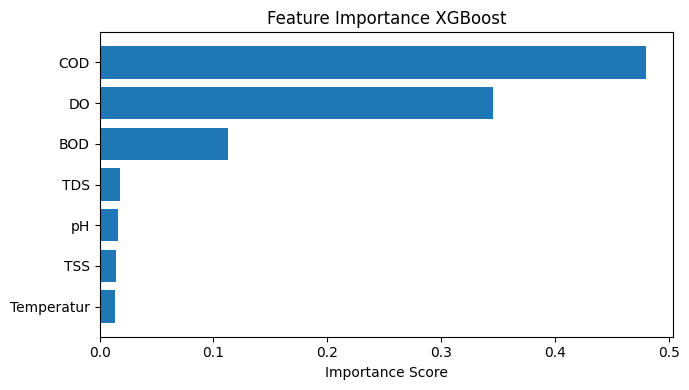

In [95]:
# Feature Importance
importances = model.feature_importances_
idx = np.argsort(importances)

plt.figure(figsize=(7,4))
plt.barh(np.array(fitur)[idx], importances[idx])
plt.xlabel("Importance Score")
plt.title("Feature Importance XGBoost")
plt.tight_layout()
plt.show()

Nilai AUC: 0.8301


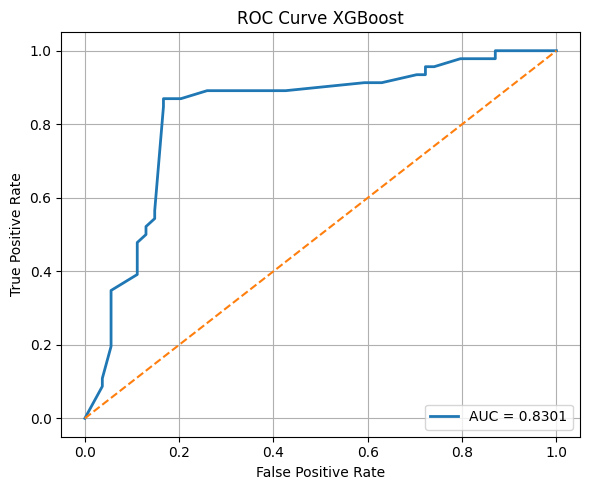

In [96]:
# =========================================
# ROC CURVE & AUC
# =========================================

# Probabilitas prediksi
y_prob = model.predict_proba(X_test)[:, 1]

# Hitung ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Hitung AUC
roc_auc = auc(fpr, tpr)

print("Nilai AUC:", round(roc_auc, 4))

# Plot ROC Curve
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, linewidth=2,
         label=f'AUC = {roc_auc:.4f}')

# Garis diagonal random classifier
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve XGBoost")
plt.legend(loc="lower right")

plt.grid(True)
plt.tight_layout()

# Tampilkan
plt.show()

In [97]:
# joblib.dump(model, "model_xgboost_kualitas_air.pkl")

# metadata = {
#     "fitur": fitur,
#     "labeling": "Indeks Pencemaran (Binary)",
#     "kelas": {
#         0: "Memenuhi Baku Mutu",
#         1: "Tidak Memenuhi Baku Mutu"
#     },
#     "baku_mutu": "PP No.22 Tahun 2021 Kelas II",
#     "time_aware": True
# }

# joblib.dump(metadata, "metadata_model.pkl")

# print("Model & metadata siap dipakai di Streamlit")

# Percobaa Kodingan


In [98]:
# # =====================================================
# # EVALUASI MODEL KNN (SEBAGAI PERBANDINGAN)
# # =====================================================

# knn_model = KNeighborsClassifier(n_neighbors=5)

# # Training
# knn_model.fit(X_train, y_train)

# # Prediksi
# y_pred_knn = knn_model.predict(X_test)

# print("\n===== HASIL EVALUASI KNN =====")
# print("Akurasi KNN:", accuracy_score(y_test, y_pred_knn))

# print(classification_report(
#     y_test,
#     y_pred_knn,
#     target_names=["Memenuhi Baku Mutu", "Tidak Memenuhi"]
# ))

# # Confusion Matrix KNN
# cm_knn = confusion_matrix(y_test, y_pred_knn)

# plt.figure(figsize=(5,4))
# plt.imshow(cm_knn, cmap="Greens")
# plt.colorbar()
# plt.xticks([0,1], ["Memenuhi", "Tidak"])
# plt.yticks([0,1], ["Memenuhi", "Tidak"])

# for i in range(2):
#     for j in range(2):
#         plt.text(j, i, cm_knn[i, j], ha="center", va="center")

# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix KNN")
# plt.tight_layout()
# plt.show()

In [99]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Fungsi evaluasi biar tidak berulang
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    }

# ================================
# SKENARIO 1: BASELINE
# ================================
baseline_results = []

model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    max_depth=4,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

res = evaluate_model(model, X_train, y_train, X_test, y_test)
res["Skenario"] = "Baseline"
baseline_results.append(res)

df_baseline = pd.DataFrame(baseline_results)
print("\n=== HASIL SKENARIO 1: BASELINE ===")
print(df_baseline)


# ================================
# SKENARIO 2: MAX_DEPTH
# ================================
depth_results = []

for depth in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        max_depth=depth,
        learning_rate=0.05,
        n_estimators=300,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    res = evaluate_model(model, X_train, y_train, X_test, y_test)
    res["Skenario"] = f"max_depth={depth}"
    depth_results.append(res)

df_depth = pd.DataFrame(depth_results)
print("\n=== HASIL SKENARIO 2: MAX_DEPTH ===")
print(df_depth.sort_values(by="Accuracy", ascending=False))


# ================================
# SKENARIO 3: LEARNING RATE
# ================================
lr_results = []

for lr in [0.01, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]:
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        max_depth=4,
        learning_rate=lr,
        n_estimators=300,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    res = evaluate_model(model, X_train, y_train, X_test, y_test)
    res["Skenario"] = f"learning_rate={lr}"
    lr_results.append(res)

df_lr = pd.DataFrame(lr_results)
print("\n=== HASIL SKENARIO 3: LEARNING RATE ===")
print(df_lr.sort_values(by="Accuracy", ascending=False))


# ================================
# SKENARIO 4: N_ESTIMATORS
# ================================
est_results = []

for n in [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]:
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        max_depth=4,
        learning_rate=0.05,
        n_estimators=n,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    res = evaluate_model(model, X_train, y_train, X_test, y_test)
    res["Skenario"] = f"n_estimators={n}"
    est_results.append(res)

df_est = pd.DataFrame(est_results)
print("\n=== HASIL SKENARIO 4: N_ESTIMATORS ===")
print(df_est.sort_values(by="Accuracy", ascending=False))

# ================================
# SKENARIO 5: SAMPLING
# ================================
sampling_results = []

for subsample in [0.7, 0.8, 1.0, 0.9, 0.6, 0.5, 0.4]:
    for colsample in [0.7, 0.8, 1.0, 0.9, 0.6]:
        model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            max_depth=4,
            learning_rate=0.05,
            n_estimators=300,
            subsample=subsample,
            colsample_bytree=colsample,
            random_state=42
        )

        res = evaluate_model(model, X_train, y_train, X_test, y_test)
        res["Skenario"] = f"sub={subsample}, col={colsample}"
        sampling_results.append(res)

df_sampling = pd.DataFrame(sampling_results)
print("\n=== HASIL SKENARIO 5: SAMPLING ===")
print(df_sampling.sort_values(by="Accuracy", ascending=False))


=== HASIL SKENARIO 1: BASELINE ===
   Accuracy  Precision    Recall  F1-Score  Skenario
0      0.84     0.8125  0.847826  0.829787  Baseline

=== HASIL SKENARIO 2: MAX_DEPTH ===
   Accuracy  Precision    Recall  F1-Score      Skenario
0      0.85   0.816327  0.869565  0.842105   max_depth=1
1      0.85   0.816327  0.869565  0.842105   max_depth=2
2      0.85   0.816327  0.869565  0.842105   max_depth=3
3      0.84   0.812500  0.847826  0.829787   max_depth=4
4      0.83   0.808511  0.826087  0.817204   max_depth=5
5      0.82   0.804348  0.804348  0.804348   max_depth=6
6      0.82   0.818182  0.782609  0.800000   max_depth=7
7      0.81   0.813953  0.760870  0.786517   max_depth=8
8      0.81   0.813953  0.760870  0.786517   max_depth=9
9      0.81   0.813953  0.760870  0.786517  max_depth=10

=== HASIL SKENARIO 3: LEARNING RATE ===
   Accuracy  Precision    Recall  F1-Score            Skenario
0      0.85   0.816327  0.869565  0.842105  learning_rate=0.01
1      0.85   0.816327  0.8

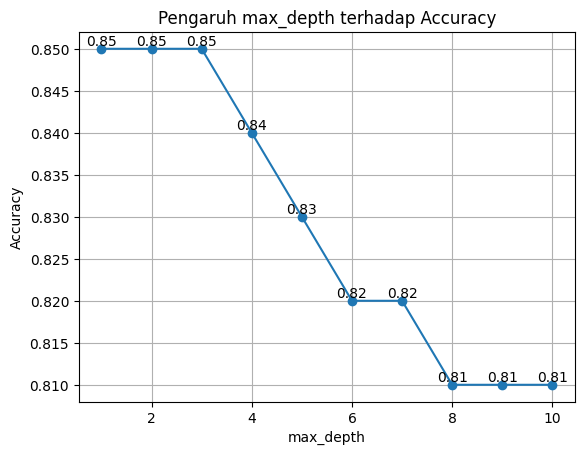

In [100]:
# VISUALISASI MAX_DEPTH
plt.figure()

# Ambil nilai depth dari string
df_depth["depth"] = df_depth["Skenario"].str.extract(r'(\d+)').astype(int)

plt.plot(df_depth["depth"], df_depth["Accuracy"], marker='o')

for i in range(len(df_depth)):
    plt.text(df_depth["depth"][i],
             df_depth["Accuracy"][i],
             round(df_depth["Accuracy"][i], 4),
             ha='center', va='bottom')

plt.title("Pengaruh max_depth terhadap Accuracy")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")

plt.grid(True)
plt.show()

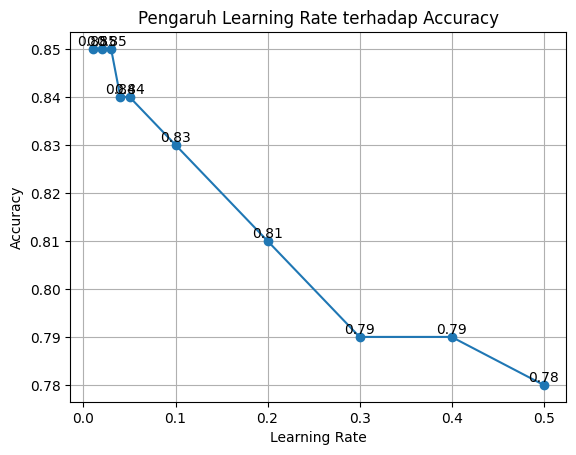

In [101]:
# VISUALISASI LEARNING RATE
plt.figure()

df_lr["lr"] = df_lr["Skenario"].str.extract(r'([\d.]+)').astype(float)

plt.plot(df_lr["lr"], df_lr["Accuracy"], marker='o')

for i in range(len(df_lr)):
    plt.text(df_lr["lr"][i],
             df_lr["Accuracy"][i],
             round(df_lr["Accuracy"][i], 4),
             ha='center', va='bottom')

plt.title("Pengaruh Learning Rate terhadap Accuracy")
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")

plt.grid(True)
plt.show()

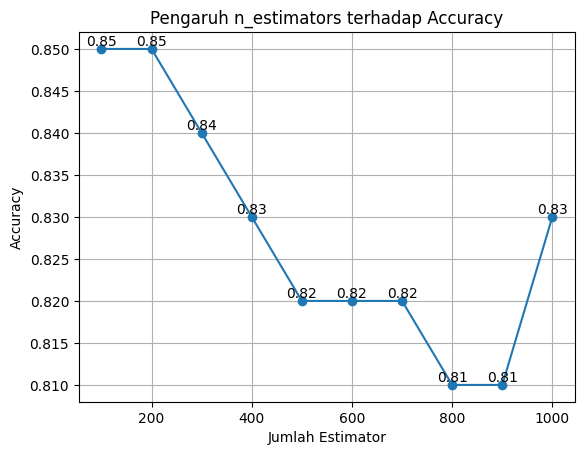

In [102]:
# VISUALISASI N_ESTIMATORS
plt.figure()

df_est["n"] = df_est["Skenario"].str.extract(r'(\d+)').astype(int)

plt.plot(df_est["n"], df_est["Accuracy"], marker='o')

for i in range(len(df_est)):
    plt.text(df_est["n"][i],
             df_est["Accuracy"][i],
             round(df_est["Accuracy"][i], 4),
             ha='center', va='bottom')

plt.title("Pengaruh n_estimators terhadap Accuracy")
plt.xlabel("Jumlah Estimator")
plt.ylabel("Accuracy")

plt.grid(True)
plt.grid(True)
plt.show()

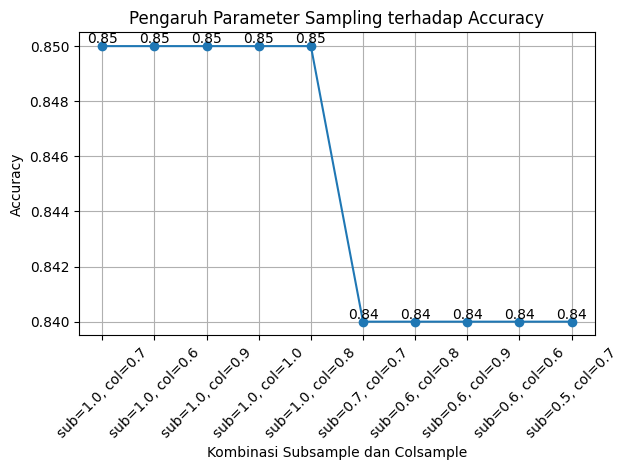

In [103]:
# ================================
# VISUALISASI SAMPLING
# ================================
plt.figure()

# Ambil 10 kombinasi terbaik
df_sampling_sorted = df_sampling.sort_values(by="Accuracy", ascending=False).head(10)

# Plot
plt.plot(range(len(df_sampling_sorted)), df_sampling_sorted["Accuracy"], marker='o')

# Tambahkan label nilai akurasi
for i in range(len(df_sampling_sorted)):
    plt.text(
        i,
        df_sampling_sorted["Accuracy"].iloc[i],
        round(df_sampling_sorted["Accuracy"].iloc[i], 4),
        ha='center',
        va='bottom'
    )

# Label sumbu X = skenario
plt.xticks(
    range(len(df_sampling_sorted)),
    df_sampling_sorted["Skenario"],
    rotation=45
)

plt.title("Pengaruh Parameter Sampling terhadap Accuracy")
plt.xlabel("Kombinasi Subsample dan Colsample")
plt.ylabel("Accuracy")

plt.grid(True)
plt.tight_layout()
plt.show()

In [104]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# ================================
# DATA
# ================================
X = data[fitur]
y = data["Target"]

# Skenario split
splits = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]

# Menyimpan hasil
hasil = []

# ================================
# LOOP SEMUA SKENARIO
# ================================
for split in splits:
    split_idx = int(split * len(data))
    
    X_train = X.iloc[:split_idx]
    X_test  = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]
    
    # Model
    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        max_depth=3,
        learning_rate=0.01,
        n_estimators=100,
        subsample=1.0,
        colsample_bytree=0.8,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    # Prediksi
    y_pred = model.predict(X_test)
    
    # Evaluasi
    acc = accuracy_score(y_test, y_pred)
    
    print("\n==============================")
    print(f"SPLIT {int(split*100)}% : {int((1-split)*100)}%")
    print("==============================")
    print("Akurasi:", round(acc, 4))
    
    print("\nClassification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=["Memenuhi Baku Mutu", "Tidak Memenuhi"]
    ))
    
    # Simpan hasil
    hasil.append({
        "Data Latih (%)": int(split*100),
        "Data Uji (%)": int((1-split)*100),
        "Akurasi": round(acc*100, 2)
    })

# ================================
# TABEL HASIL
# ================================
df_hasil = pd.DataFrame(hasil)
print("\n=== RINGKASAN HASIL ===")
print(df_hasil)


SPLIT 90% : 9%
Akurasi: 0.85

Classification Report:
                    precision    recall  f1-score   support

Memenuhi Baku Mutu       0.88      0.83      0.86        54
    Tidak Memenuhi       0.82      0.87      0.84        46

          accuracy                           0.85       100
         macro avg       0.85      0.85      0.85       100
      weighted avg       0.85      0.85      0.85       100


SPLIT 80% : 19%
Akurasi: 0.82

Classification Report:
                    precision    recall  f1-score   support

Memenuhi Baku Mutu       0.84      0.83      0.83       109
    Tidak Memenuhi       0.80      0.81      0.80        91

          accuracy                           0.82       200
         macro avg       0.82      0.82      0.82       200
      weighted avg       0.82      0.82      0.82       200


SPLIT 70% : 30%
Akurasi: 0.82

Classification Report:
                    precision    recall  f1-score   support

Memenuhi Baku Mutu       0.85      0.83      0.84

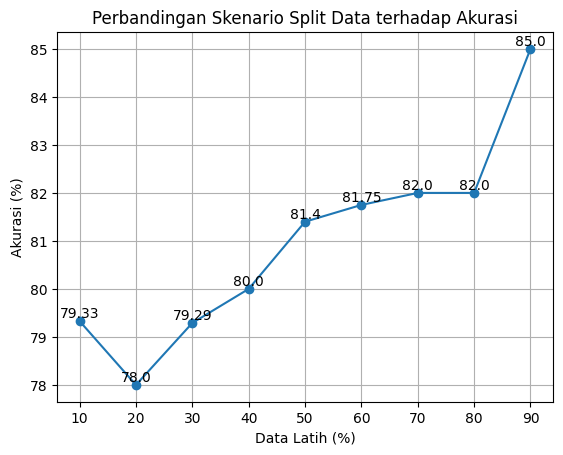

In [105]:
import matplotlib.pyplot as plt

# ================================
# VISUALISASI LINE CHART
# ================================
plt.figure()

# Plot line + marker titik
plt.plot(df_hasil["Data Latih (%)"], df_hasil["Akurasi"], marker='o')

# Tambahkan label di setiap titik
for i, txt in enumerate(df_hasil["Akurasi"]):
    plt.text(
        df_hasil["Data Latih (%)"][i],
        df_hasil["Akurasi"][i],
        str(txt),
        ha='center',
        va='bottom'
    )

# Judul dan label sumbu
plt.title("Perbandingan Skenario Split Data terhadap Akurasi")
plt.xlabel("Data Latih (%)")
plt.ylabel("Akurasi (%)")

# Grid (background kotak-kotak)
plt.grid(True)

# Tampilkan plot
plt.show()

In [106]:
# # =====================================================
# # EXPORT HASIL FINAL PENELITIAN
# # =====================================================

# import os
# import zipfile
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.metrics import classification_report, confusion_matrix
# import joblib

# # ===============================
# # BUAT FOLDER OUTPUT
# # ===============================
# OUTPUT_DIR = "HASIL_PENELITIAN_XGBOOST"
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# # ===============================
# # 1. DATA MENTAH (5 BARIS)
# # ===============================
# data.head(5).to_excel(
#     f"{OUTPUT_DIR}/01_data_mentah_5_baris.xlsx",
#     index=False
# )

# # ===============================
# # 2. CLASSIFICATION REPORT
# # ===============================
# # Prediksi
# y_pred = model_final.predict(X_test_final)

# # Simpan hasil final (biar tidak ketimpa)
# y_pred_final = y_pred.copy()

# # Export classification report
# report = classification_report(
#     y_test_final,
#     y_pred_final,
#     target_names=["Memenuhi Baku Mutu", "Tidak Memenuhi"],
#     output_dict=True
# )

# pd.DataFrame(report).transpose().to_excel(
#     f"{OUTPUT_DIR}/02_classification_report.xlsx"
# )

# # ===============================
# # 3. CONFUSION MATRIX
# # ===============================
# cm = confusion_matrix(y_test_final, y_pred_final)

# plt.figure(figsize=(5,4))
# plt.imshow(cm, cmap="Blues")
# plt.colorbar()
# plt.xticks([0,1], ["Memenuhi", "Tidak"])
# plt.yticks([0,1], ["Memenuhi", "Tidak"])

# for i in range(2):
#     for j in range(2):
#         plt.text(j, i, cm[i, j], ha="center", va="center")

# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.title("Confusion Matrix")
# plt.tight_layout()
# plt.savefig(f"{OUTPUT_DIR}/03_confusion_matrix.png")
# plt.close()

# # ===============================
# # 4. FEATURE IMPORTANCE
# # ===============================
# importances = model_final.feature_importances_
# idx = np.argsort(importances)

# plt.figure(figsize=(7,4))
# plt.barh(np.array(fitur)[idx], importances[idx])
# plt.xlabel("Importance Score")
# plt.title("Feature Importance XGBoost")
# plt.tight_layout()
# plt.savefig(f"{OUTPUT_DIR}/04_feature_importance.png")
# plt.close()

# # ===============================
# # 5. HASIL SKENARIO (TABEL)
# # ===============================
# df_hasil.to_excel(f"{OUTPUT_DIR}/05_split_data.xlsx", index=False)
# df_baseline.to_excel(f"{OUTPUT_DIR}/06_baseline.xlsx", index=False)
# df_depth.to_excel(f"{OUTPUT_DIR}/07_max_depth.xlsx", index=False)
# df_lr.to_excel(f"{OUTPUT_DIR}/08_learning_rate.xlsx", index=False)
# df_est.to_excel(f"{OUTPUT_DIR}/09_n_estimators.xlsx", index=False)
# df_sampling.to_excel(f"{OUTPUT_DIR}/10_sampling.xlsx", index=False)

# # ===============================
# # 6. GRAFIK SKENARIO
# # ===============================

# # --- SPLIT DATA ---
# plt.figure()
# plt.plot(df_hasil["Data Latih (%)"], df_hasil["Akurasi"], marker='o')
# for i in range(len(df_hasil)):
#     plt.text(df_hasil["Data Latih (%)"][i],
#              df_hasil["Akurasi"][i],
#              df_hasil["Akurasi"][i],
#              ha='center', va='bottom')
# plt.title("Split Data dan Akurasi")
# plt.xlabel("Data Latih (%)")
# plt.ylabel("Akurasi (%)")
# plt.grid(True)
# plt.savefig(f"{OUTPUT_DIR}/11_split_data.png")
# plt.close()

# # --- MAX DEPTH ---
# df_depth["depth"] = df_depth["Skenario"].str.extract(r'(\d+)').astype(int)

# plt.figure()
# plt.plot(df_depth["depth"], df_depth["Accuracy"], marker='o')
# for i in range(len(df_depth)):
#     plt.text(df_depth["depth"][i],
#              df_depth["Accuracy"][i],
#              round(df_depth["Accuracy"][i], 4),
#              ha='center', va='bottom')
# plt.title("Max Depth dan Accuracy")
# plt.xlabel("Max Depth")
# plt.ylabel("Accuracy")
# plt.grid(True)
# plt.savefig(f"{OUTPUT_DIR}/12_max_depth.png")
# plt.close()

# # --- LEARNING RATE ---
# df_lr["lr"] = df_lr["Skenario"].str.extract(r'([\d.]+)').astype(float)

# plt.figure()
# plt.plot(df_lr["lr"], df_lr["Accuracy"], marker='o')
# for i in range(len(df_lr)):
#     plt.text(df_lr["lr"][i],
#              df_lr["Accuracy"][i],
#              round(df_lr["Accuracy"][i], 4),
#              ha='center', va='bottom')
# plt.title("Learning Rate dan Accuracy")
# plt.xlabel("Learning Rate")
# plt.ylabel("Accuracy")
# plt.grid(True)
# plt.savefig(f"{OUTPUT_DIR}/13_learning_rate.png")
# plt.close()

# # --- N ESTIMATORS ---
# df_est["n"] = df_est["Skenario"].str.extract(r'(\d+)').astype(int)

# plt.figure()
# plt.plot(df_est["n"], df_est["Accuracy"], marker='o')
# for i in range(len(df_est)):
#     plt.text(df_est["n"][i],
#              df_est["Accuracy"][i],
#              round(df_est["Accuracy"][i], 4),
#              ha='center', va='bottom')
# plt.title("n_estimators dan Accuracy")
# plt.xlabel("n_estimators")
# plt.ylabel("Accuracy")
# plt.grid(True)
# plt.savefig(f"{OUTPUT_DIR}/14_n_estimators.png")
# plt.close()

# # --- SAMPLING (TOP 10) ---
# df_sampling_sorted = df_sampling.sort_values(by="Accuracy", ascending=False).head(10)

# plt.figure()
# plt.plot(range(len(df_sampling_sorted)), df_sampling_sorted["Accuracy"], marker='o')

# for i in range(len(df_sampling_sorted)):
#     plt.text(i,
#              df_sampling_sorted["Accuracy"].iloc[i],
#              round(df_sampling_sorted["Accuracy"].iloc[i], 4),
#              ha='center', va='bottom')

# plt.xticks(range(len(df_sampling_sorted)),
#            df_sampling_sorted["Skenario"],
#            rotation=45)

# plt.title("Sampling")
# plt.xlabel("Skenario")
# plt.ylabel("Accuracy")
# plt.grid(True)
# plt.tight_layout()
# plt.savefig(f"{OUTPUT_DIR}/15_sampling.png")
# plt.close()

# # ===============================
# # 7. SIMPAN MODEL
# # ===============================
# joblib.dump(model_final, f"{OUTPUT_DIR}/16_model_xgboost.pkl")

# # ===============================
# # 8. ZIP SEMUA HASIL
# # ===============================
# ZIP_NAME = "HASIL_PENELITIAN_XGBOOST.zip"

# with zipfile.ZipFile(ZIP_NAME, "w", zipfile.ZIP_DEFLATED) as zipf:
#     for file in os.listdir(OUTPUT_DIR):
#         zipf.write(os.path.join(OUTPUT_DIR, file), arcname=file)

# # ===============================
# # ROC CURVE
# # ===============================

# from sklearn.metrics import roc_curve, auc

# # Probabilitas prediksi
# y_prob = model_final.predict_proba(X_test_final)[:, 1]

# # Hitung ROC
# fpr, tpr, thresholds = roc_curve(y_test_final, y_prob)

# # Hitung AUC
# roc_auc = auc(fpr, tpr)

# print("Nilai AUC:", round(roc_auc, 4))

# # Plot ROC
# plt.figure(figsize=(6,5))

# plt.plot(
#     fpr,
#     tpr,
#     linewidth=2,
#     label=f'AUC = {roc_auc:.4f}'
# )

# # Garis diagonal
# plt.plot([0,1], [0,1], linestyle='--')

# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve XGBoost")
# plt.legend(loc="lower right")

# plt.grid(True)
# plt.tight_layout()

# # Simpan ke folder penelitian
# plt.savefig(f"{OUTPUT_DIR}/16_roc_curve.png")

# plt.close()

# print("✅ EXPORT SELESAI")
# print(f"📦 File: {ZIP_NAME}")